<a href="https://colab.research.google.com/github/Abdi-dotcom/Construction--equipment-Tracking/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import torch #The main PyTorch library, used for tensors and operations
from torch import nn
from sklearn.model_selection import train_test_split

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive



In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:

file_path = '/content/drive/MyDrive/Colab Notebooks/used_cars.csv'
car = pd.read_csv(file_path)

In [4]:
car.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
car.shape

(4009, 12)

In [6]:
milage = car["milage"]
milage = milage.str.replace(",", "")
milage = milage.str.replace(" mi.", "")
milage = milage.astype(int)
print(milage)

0       51000
1       34742
2       22372
3       88900
4        9835
        ...  
4004      714
4005    10900
4006     2116
4007    33000
4008    43000
Name: milage, Length: 4009, dtype: int64


In [7]:
age = car["model_year"].max() - car["model_year"]
print(age)

0       11
1        3
2        2
3        9
4        3
        ..
4004     1
4005     2
4006     2
4007     4
4008     4
Name: model_year, Length: 4009, dtype: int64


In [8]:
price = car["price"]
price = price.str.replace("$", "")
price = price.str.replace(",", "")
price = price.astype(int)
print(price)

0        10300
1        38005
2        54598
3        15500
4        34999
         ...  
4004    349950
4005     53900
4006     90998
4007     62999
4008     40000
Name: price, Length: 4009, dtype: int64


Build tensors

In [9]:
#converting to PyTorch tensors,
X = torch.stack([torch.tensor(milage, dtype=torch.float32),
                 torch.tensor(age, dtype=torch.float32)], dim=1)
print(X)
print(X.shape)

tensor([[5.1000e+04, 1.1000e+01],
        [3.4742e+04, 3.0000e+00],
        [2.2372e+04, 2.0000e+00],
        ...,
        [2.1160e+03, 2.0000e+00],
        [3.3000e+04, 4.0000e+00],
        [4.3000e+04, 4.0000e+00]])
torch.Size([4009, 2])


In [21]:
Y= torch.tensor(price, dtype=torch.float32).reshape((-1,1))
print("X shape:", X.shape)   # (N, 2)
print("Y shape:", Y.shape)   # (N, 1)

X shape: torch.Size([4009, 2])
Y shape: torch.Size([4009, 1])


In [11]:
X_mean = X.mean(dim=0)
X_std = X.std(dim=0)
X = (X - X_mean) / X_std
print(X_mean)
print(X_std)
print(X)

tensor([6.4718e+04, 8.4844e+00])
tensor([5.2297e+04, 6.1048e+00])
tensor([[-0.2623,  0.4121],
        [-0.5732, -0.8984],
        [-0.8097, -1.0622],
        ...,
        [-1.1970, -1.0622],
        [-0.6065, -0.7346],
        [-0.4153, -0.7346]])


In [12]:
Y_mean = Y.mean(dim=0)
Y_std = Y.std()
Y = (Y - Y_mean) / Y_std
print(Y_mean)
print(Y_std)
print(Y)

tensor([44553.1875])
tensor(78710.6328)
tensor([[-0.4352],
        [-0.0832],
        [ 0.1276],
        ...,
        [ 0.5901],
        [ 0.2343],
        [-0.0578]])


In [13]:
# define model
model = nn.Linear(2, 1)

In [14]:
#define loss function
criteria = nn.MSELoss()

In [15]:
#define optimiser
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Training a Neural Network

In [16]:
epochs = 1000 # number of times passes through the entire training set
losses = []
for i in range(0, epochs):
  optimizer.zero_grad()
  preds = model(X)
  loss = criteria(preds, Y)
  loss.backward()
  optimizer.step()

  if i% 100 == 0:
    print ("loss: ", loss)
  losses.append(loss.item())

loss:  tensor(1.1040, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9088, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9063, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9063, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)


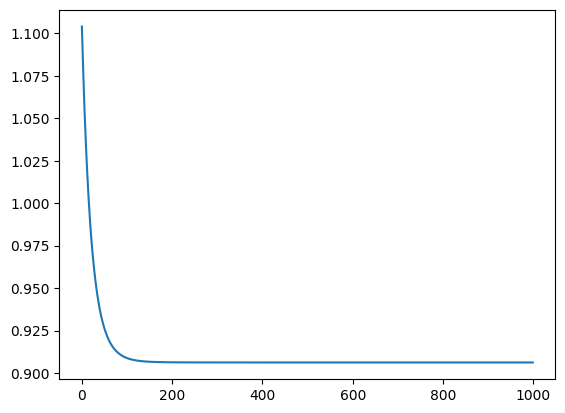

In [17]:
plt.plot(losses)
plt.show()

Making predications

In [18]:
from numpy import dtype
model.eval()
with torch.no_grad():
  X_new = torch.tensor([
      [10000, 2],
      [20000, 2]
      ],dtype = torch.float32)
  X_new = (X_new - X_mean) / X_std
  Prediction = model(X_new)
  Prediction = (Prediction * Y_std) + Y_mean
  print(Prediction)

tensor([[70284.5781],
        [65848.2656]])


Split into train and test

In [22]:
X_np = X.numpy()
Y_np = Y.numpy()

X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(
    X_np, Y_np, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np, dtype=torch.float32)
Y_train = torch.tensor(Y_train_np, dtype=torch.float32)
Y_test  = torch.tensor(Y_test_np, dtype=torch.float32)


Standardised using train statistics only

In [23]:
X_mean = X_train.mean(dim=0)
X_std = X_train.std(dim=0)

X_train = (X_train - X_mean) / X_std # (value - mean) / std
X_test  = (X_test  - X_mean) / X_std   # use train mean/std

Y_mean = Y_train.mean(dim=0)
Y_std = Y_train.std()

Y_train = (Y_train - Y_mean) / Y_std
Y_test  = (Y_test  - Y_mean) / Y_std


Define model, loss, optimiser

In [24]:
model = nn.Linear(2, 1) #mean Input size = 2 (mileage and age),Output size = 1 (predicted price).
# The model learns these weights/bias so that price = w1 * mileage_scaled + w2 * age_scaled + b.
criteria = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
#model.parameters(): Gives all the weights and biases that we want to adjust.
# SGD: Stochastic Gradient Descent – an algorithm that moves parameters in the direction that reduces loss
# lr=0.01: Learning rate – how big a step we take each update. Too big = unstable; too small = slow.


In [25]:
#Training loop with train and test loss

epochs = 500 # number of times we go through the whole training set
train_losses = []
test_losses = []

for epoch in range(epochs): #loop over epochs
    # TRAIN
    model.train()
    optimizer.zero_grad()
    preds_train = model(X_train)
    loss_train = criteria(preds_train, Y_train)
    loss_train.backward()
    optimizer.step()

    # EVAL
    model.eval()
    with torch.no_grad():
        preds_test = model(X_test)
        loss_test = criteria(preds_test, Y_test)

    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train loss: {loss_train.item():.4f} | Test loss: {loss_test.item():.4f}")


Epoch   0 | Train loss: 2.2128 | Test loss: 8.6569
Epoch  50 | Train loss: 0.8710 | Test loss: 7.5174
Epoch 100 | Train loss: 0.8018 | Test loss: 7.5136
Epoch 150 | Train loss: 0.7957 | Test loss: 7.5352
Epoch 200 | Train loss: 0.7946 | Test loss: 7.5482
Epoch 250 | Train loss: 0.7942 | Test loss: 7.5561
Epoch 300 | Train loss: 0.7941 | Test loss: 7.5610
Epoch 350 | Train loss: 0.7940 | Test loss: 7.5643
Epoch 400 | Train loss: 0.7940 | Test loss: 7.5664
Epoch 450 | Train loss: 0.7939 | Test loss: 7.5679


plot the losses

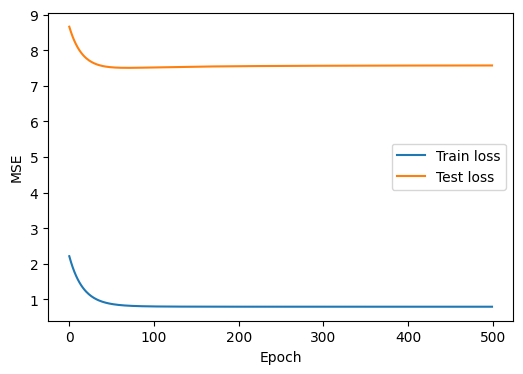

In [26]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

making predication in original price units

In [28]:
model.eval()
with torch.no_grad():
    X_new = torch.tensor([[10000, 2],
                          [20000, 2]], dtype=torch.float32)
    X_new_scaled = (X_new - X_mean) / X_std
    pred_scaled = model(X_new_scaled)
    pred_price = (pred_scaled * Y_std) + Y_mean
    print("Predicted prices:\n", pred_price)


Predicted prices:
 tensor([[-1.8614e+08],
        [-3.7231e+08]])


define MLP model

In [29]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criteria = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


re run the same traiing loop

In [31]:
epochs = 500
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    preds_train = model(X_train)
    loss_train = criteria(preds_train, Y_train)
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        preds_test = model(X_test)
        loss_test = criteria(preds_test, Y_test)

    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train loss: {loss_train.item():.4f} | Test loss: {loss_test.item():.4f}")


Epoch   0 | Train loss: 0.9882 | Test loss: 7.7562
Epoch  50 | Train loss: 0.6723 | Test loss: 7.3306
Epoch 100 | Train loss: 0.6215 | Test loss: 7.3452
Epoch 150 | Train loss: 0.6150 | Test loss: 7.3418
Epoch 200 | Train loss: 0.6128 | Test loss: 7.3348
Epoch 250 | Train loss: 0.6110 | Test loss: 7.3568
Epoch 300 | Train loss: 0.6094 | Test loss: 7.3791
Epoch 350 | Train loss: 0.6082 | Test loss: 7.3969
Epoch 400 | Train loss: 0.6074 | Test loss: 7.4022
Epoch 450 | Train loss: 0.6069 | Test loss: 7.4017


Add mini-batch training with DataLoader

In [32]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test, Y_test)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=64, shuffle=False)

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 300
train_losses = []
test_losses = []

for epoch in range(epochs):
    # TRAIN over batches
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_ds)

    # EVAL
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_dl:
            preds = model(xb)
            loss = criterion(preds, yb)
            running_test_loss += loss.item() * xb.size(0)
    epoch_test_loss = running_test_loss / len(test_ds)

    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train loss: {epoch_train_loss:.4f} | Test loss: {epoch_test_loss:.4f}")


Epoch   0 | Train loss: 0.7437 | Test loss: 7.4316
Epoch  50 | Train loss: 0.6416 | Test loss: 7.3420
Epoch 100 | Train loss: 0.6373 | Test loss: 7.3587
Epoch 150 | Train loss: 0.6173 | Test loss: 7.4112
Epoch 200 | Train loss: 0.6292 | Test loss: 7.3988
Epoch 250 | Train loss: 0.6434 | Test loss: 7.3961


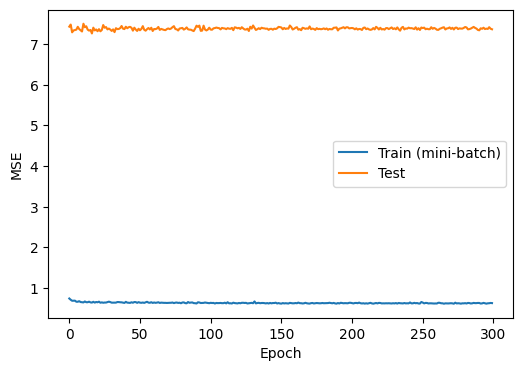

In [33]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train (mini-batch)")
plt.plot(test_losses, label="Test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()